In [1]:
!pip install ultralytics

Определение детектора, совместимого с YOLO

In [1]:
from pathlib import Path
from typing import Optional, Union

import numpy as np
from ultralytics import YOLO

from manuscript.data import Block, Line, Page, TextSpan
from manuscript.utils import organize_page, read_image


class YoloDetector:
    def __init__(
        self,
        weights: Union[str, Path],
        conf: float = 0.25,
        iou: float = 0.7,
        imgsz: int = 640,
        device: Optional[str] = None,
        sort_reading_order: bool = True,
        split_into_columns: bool = True,
        max_columns: int = 10,
    ):
        self.conf = conf
        self.iou = iou
        self.imgsz = imgsz
        self.sort_reading_order = sort_reading_order
        self.split_into_columns = split_into_columns
        self.max_columns = max_columns

        self.model = YOLO(str(weights))
        if device:
            self.model.to(device)

        self.last_raw_result = None

    def predict(self, image: Union[str, Path, np.ndarray], **kwargs) -> Page:
        image_array = read_image(image)

        result = self.model.predict(
            image_array,
            conf=self.conf,
            iou=self.iou,
            imgsz=self.imgsz,
            verbose=False,
        )[0]
        self.last_raw_result = result

        boxes = result.boxes.data.tolist() if result.boxes is not None else []
        text_spans = [
            TextSpan(
                polygon=[(x1, y1), (x2, y1), (x2, y2), (x1, y2)],
                detection_confidence=float(conf),
            )
            for x1, y1, x2, y2, conf, _ in boxes
        ]

        page = Page(
            blocks=[Block(lines=[Line(text_spans=text_spans, order=0)], order=0)]
        )

        if self.sort_reading_order and text_spans:
            return organize_page(
                page,
                max_splits=self.max_columns,
                use_columns=self.split_into_columns,
            )

        for i, span in enumerate(text_spans):
            span.order = i

        return page

c:\Users\USER\manuscript-ocr-2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


c:\Users\USER\manuscript-ocr-2\.venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\USER\.cache\huggingface\hub\models--Daniil-Domino--yolo11x-text-detection. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


[TRBA] Device configuration:
  Requested device: cuda
  Requested providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']
  Active providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']
  Running on: CUDAExecutionProvider
[CharLM] Device configuration:
  Requested device: cuda
  Requested providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']
  Active providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']
  Running on: CUDAExecutionProvider
{'page': Page(blocks=[Block(lines=[Line(text_spans=[TextSpan(polygon=[(317.00018310546875, 473.3851013183594), (410.50872802734375, 473.3851013183594), (410.50872802734375, 545.6807250976562), (317.00018310546875, 545.6807250976562)], detection_confidence=0.6580857038497925, text='3)', recognition_confidence=0.7183986902236938, order=0)], order=0)], text_spans=[], order=0), Block(lines=[Line(text_spans=[TextSpan(polygon=[(442.2515563964844, 444.135986328125), (690.57763671875, 444.135986328125), (690.57763671875, 543.429809570

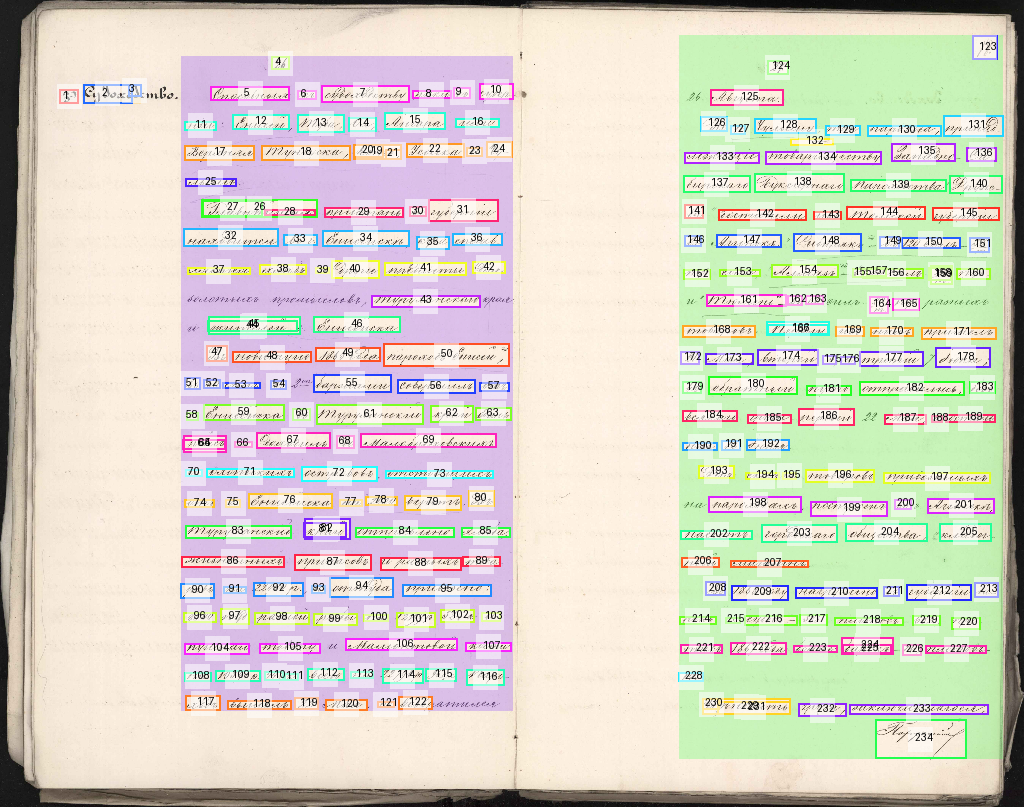

In [2]:
from huggingface_hub import hf_hub_download

from manuscript import Pipeline
from manuscript.utils.visualization import visualize_page
from manuscript.recognizers import TRBA
from manuscript.correctors import CharLM


model_path = hf_hub_download(repo_id="Daniil-Domino/yolo11x-text-detection", filename="model.pt")
image_path = r"C:\Users\USER\manuscript-ocr-2\example\ocr_example_image.jpg"

pipeline = Pipeline(
    detector=YoloDetector(
        weights=model_path,
        conf=0.25,
    ), # Детектор Daniil-Domino/yolo11x-text-detection, совместимый с manuscript благодаря классу-обёртке YoloDetector
    recognizer=TRBA(weights="trba_lite_g1"),
    corrector=CharLM(weights="modern_charlm_g1"),
)

# Запуск пайплайна
result = pipeline.predict(image_path)

# Весь объект результата
print(result)

# Текст
text = pipeline.get_text(result["page"])
print(text)

# Визуализация
visualize_page(image_path, result["page"], show_lines=False, show_numbers=True, max_size = 1024)